# PCLab#1 - Group 4 - Claas Boumans Giuliano Ciaramella Theodor Nissen-Meyer

**20598 – Finance with Big Data · PC Lab #1: Applied Portfolio Theory**

## 0. Setup

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

pd.set_option("display.float_format", "{:,.4f}".format)

DAYS = 252             # trading days per year, used to annualise daily numbers
N_PORTFOLIOS = 10_000  # number of random portfolios in the simulation
SEED = 42              # fixed random seed, so every run gives the same results

In [29]:
# Chart theme inspired by The Economist: white background, horizontal gridlines,
# bold left-aligned titles, red rule at the top, and the magazine's blue/teal palette.
ECONOMIST_RED = "#E3120B"
ECONOMIST_COLORS = ["#006BA2", "#3EBCD2", "#379A8B", "#EBB434", "#B4BA39",
                    "#9A607F", "#D1B07C", "#758D99", "#DB444B"]

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.prop_cycle": plt.cycler(color=ECONOMIST_COLORS),   # line and bar colours
    "axes.grid": True,
    "axes.grid.axis": "y",                                  # horizontal gridlines only
    "grid.color": "#D0D0D0",
    "axes.axisbelow": True,                                 # gridlines behind bars and points
    "axes.spines.top": False,                               # only the bottom axis line stays
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "ytick.left": False,                                    # no tick marks on the y axis
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})

# Colour maps in the same palette
ECONOMIST_BLUES = LinearSegmentedColormap.from_list("economist_blues", ["#C5E4F0", "#3EBCD2", "#006BA2", "#0C2A4A"])
ECONOMIST_DIVERGING = LinearSegmentedColormap.from_list("economist_diverging", ["#DB444B", "white", "#006BA2"])


def show():
    '''Add the red line and red tag at the top of the current figure, then display it.'''
    fig = plt.gcf()
    fig.tight_layout()
    fig.add_artist(plt.Line2D([0, 1], [1.02, 1.02], transform=fig.transFigure, color=ECONOMIST_RED, lw=1.5))
    fig.add_artist(plt.Rectangle((0, 1.02), 0.035, 0.015, transform=fig.transFigure, color=ECONOMIST_RED, clip_on=False))
    plt.show()

## Task #1 – Import the data and describe the sample
We read the CSV, parse the dates, sort chronologically and index by date.

In [30]:
prices = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
prices = prices.sort_values("Date").set_index("Date")

stocks = list(prices.columns.drop("sp500"))   # the eight stocks (everything except the index)

print("Sample:", prices.index.min().date(), "to", prices.index.max().date(), f"({len(prices)} trading days)")
print("Number of stocks:", len(stocks), stocks)
prices.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data_PCLab1_Stock.csv'

**Null values.** Missing prices would break the return and covariance calculations.

In [ ]:
print("Missing values:", int(prices.isnull().values.sum()))

Missing values: 0


**Descriptive statistics.** `describe()` answers the three questions below. We add the coefficient of variation (std / mean), because dispersion in dollars also reflects the price level.

In [ ]:
summary = prices.describe().T
summary["coef_var"] = summary["std"] / summary["mean"]
summary

,count,mean,std,min,25%,50%,75%,max,coef_var
AAPL,"2,159.0000",140.8198,70.8276,55.7900,89.1657,116.6000,175.0200,455.6100,0.5030
BA,"2,159.0000",189.9427,103.6786,67.2400,124.0150,142.4200,297.0450,440.6200,0.5458
T,"2,159.0000",35.1629,3.2075,26.7700,33.0400,34.9300,37.4200,43.4700,0.0912
MGM,"2,159.0000",23.1057,6.9638,7.1400,18.5450,23.7800,28.4300,38.0300,0.3014
AMZN,"2,159.0000",915.6657,697.8389,175.9300,316.4900,676.0100,"1,593.6450","3,225.0000",0.7621
IBM,"2,159.0000",161.8530,25.5619,94.7700,142.7700,156.9500,185.9750,215.8000,0.1579
TSLA,"2,159.0000",259.6008,210.9880,22.7900,184.5950,231.9600,307.3500,"1,643.0000",0.8127
GOOG,"2,159.0000",783.7125,334.4481,278.4812,527.2144,737.6000,"1,079.7450","1,568.4900",0.4267
sp500,"2,159.0000","2,218.7496",537.3217,"1,278.0400","1,847.9850","2,106.6299","2,705.8101","3,386.1499",0.2422


In [ ]:
print("Average value of the S&P 500 :", round(prices["sp500"].mean(), 2))
print("Lowest std in dollars       :", prices.std().idxmin(), round(prices.std().min(), 2))
print("Lowest coefficient of var.  :", summary["coef_var"].idxmin(), round(summary["coef_var"].min(), 3))
print("Maximum Amazon price        :", prices["AMZN"].max(), "on", prices["AMZN"].idxmax().date())

Average value of the S&P 500 : 2218.75
Lowest std in dollars       : T 3.21
Lowest coefficient of var.  : T 0.091
Maximum Amazon price        : 3225.0 on 2020-08-06


**Answers – Task #1**
- **Sample:** 2,159 trading days from 2012-01-12 to 2020-08-11, eight stocks plus the S&P 500, no missing values.
- **Average S&P 500 level:** 2,218.75 points.
- **Lowest dispersion in dollars:** AT&T, std \$3.21 (range \$26.77–\$43.47). It is also lowest on the coefficient of variation (0.09), so this is not only an effect of its low share price.
- **Highest Amazon price:** \$3,225.00 on 2020-08-06.

## Task #2 – Plot the data

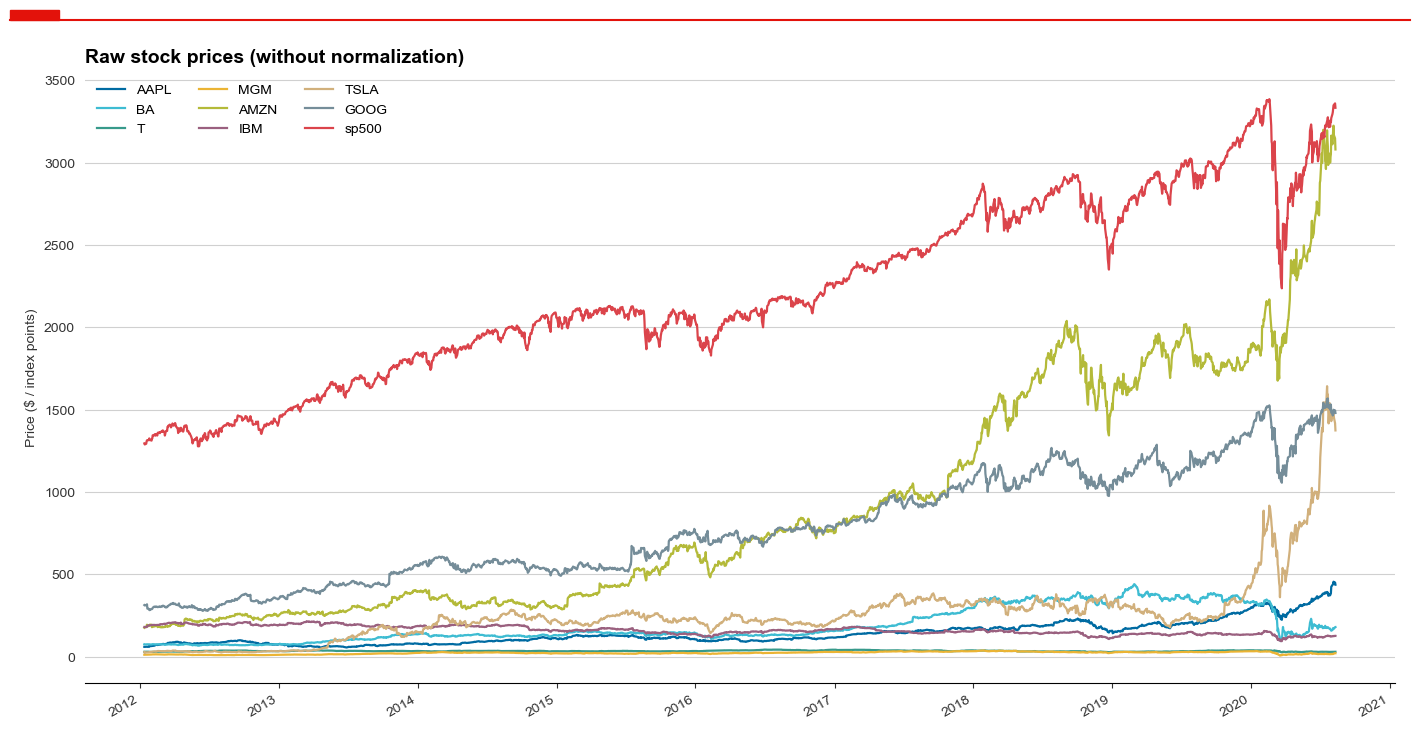

In [ ]:
def plot_financial_data(df, title, ylabel="", log_scale=False):
    '''Plot every column of df against the date index.'''
    ax = df.plot(figsize=(14, 7))
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(False, axis="x")                                # pandas adds vertical gridlines for dates
    ax.legend(loc="upper left", ncol=3)

    if log_scale:
        ax.set_yscale("log")
        # readable tick labels instead of powers of ten (finer steps when the values lie close together)
        low, high = df.min().min(), df.max().max()
        candidates = [0.5, 1, 2, 5, 10, 20, 50, 100] if high / low > 10 else [0.5, 0.75, 1, 1.5, 2, 3, 4, 5]
        ticks = [t for t in candidates if low <= t <= high]
        ax.set_yticks(ticks, labels=[f"{t:g}" for t in ticks])
        ax.minorticks_off()

    show()


plot_financial_data(prices, "Raw stock prices (without normalization)", "Price ($ / index points)")

The chart shows price *levels*, not performance: the S&P 500 (1,300–3,400 points), Amazon and Google dominate the scale. A \$30 stock can grow faster than a \$3,000 one, so Task 3 rebases every series.

## Task #3 – Normalized (scaled) stock prices

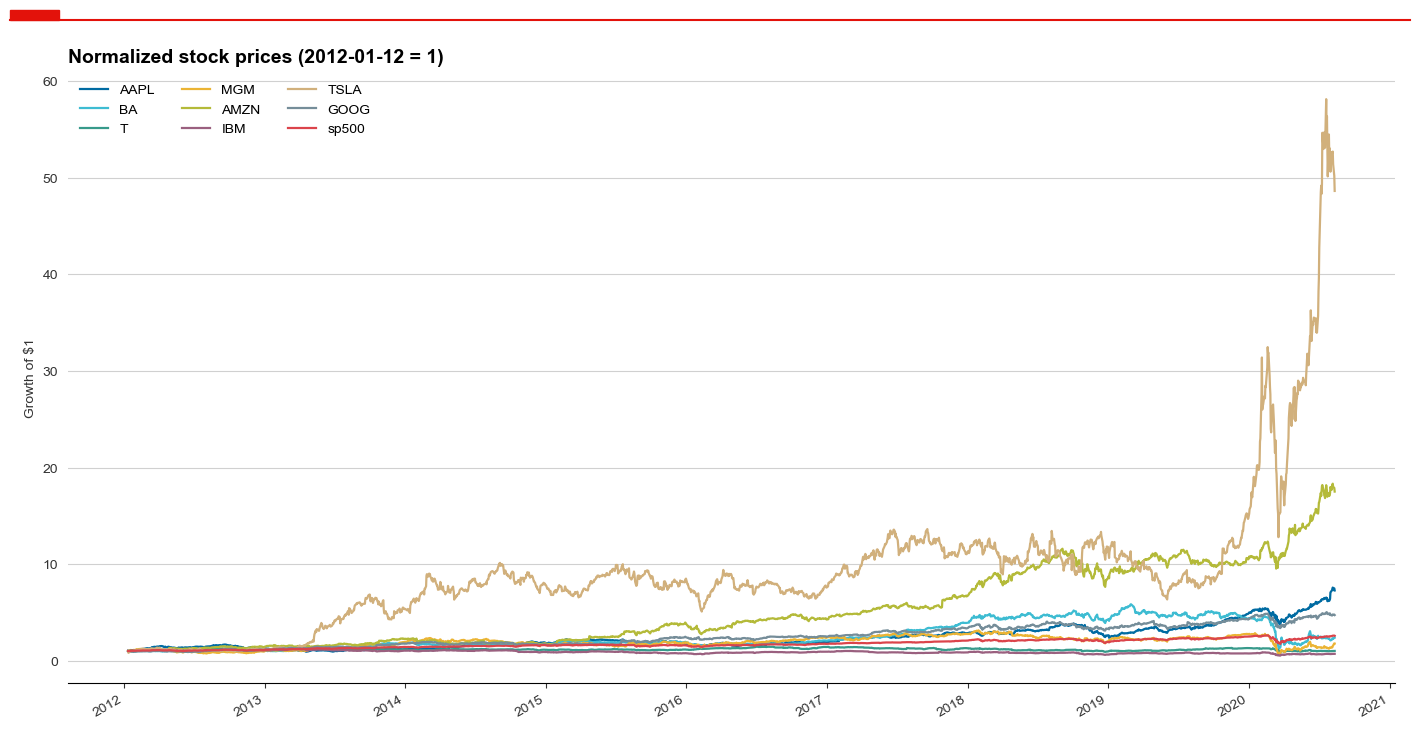

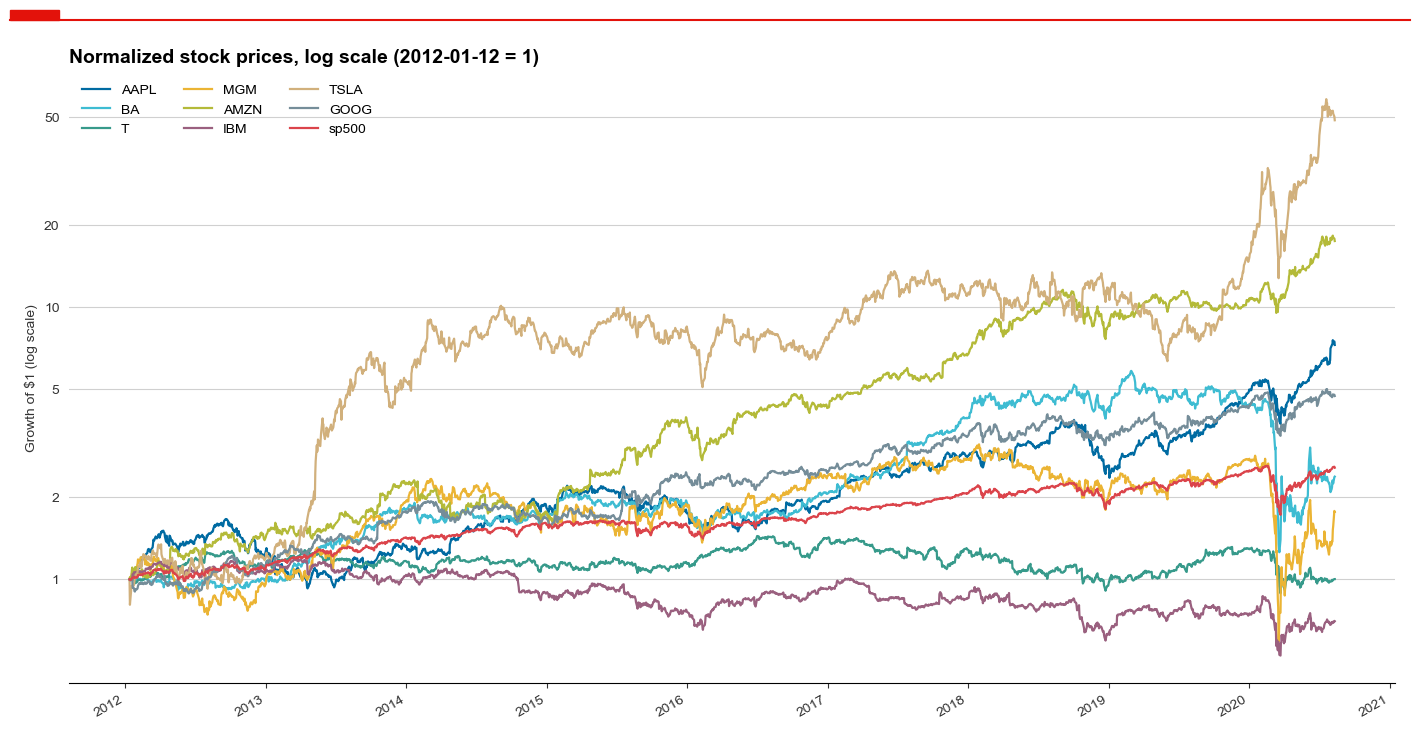

Value of $1 invested on 2012-01-12 at the end of the sample:
TSLA    48.6500
AMZN    17.5100
AAPL     7.2700
GOOG     4.7200
sp500    2.5700
BA       2.3900
MGM      1.7700
T        1.0000
IBM      0.7000
Name: 2020-08-11 00:00:00, dtype: float64


In [ ]:
def normalize(df):
    '''Divide every column by its first value, so each series starts at 1.'''
    return df / df.iloc[0]


normalized_prices = normalize(prices)
plot_financial_data(normalized_prices, "Normalized stock prices (2012-01-12 = 1)", "Growth of $1")
plot_financial_data(normalized_prices, "Normalized stock prices, log scale (2012-01-12 = 1)", "Growth of $1 (log scale)", log_scale=True)

print("Value of $1 invested on 2012-01-12 at the end of the sample:")
print(normalized_prices.iloc[-1].sort_values(ascending=False).round(2))

**Why the log scale?** Equal vertical distances are equal percentage changes, so 1 → 2 looks like 10 → 20. On the linear chart Tesla's 2020 jump flattens everything else; on the log chart Amazon's steady compounding is almost a straight line, Tesla's 2013 surge becomes visible, and AT&T and IBM are clearly flat or below 1.

**Comment**
- Tesla turned \$1 into \$48.65, most of it in 2020. Amazon (×17.5), Apple (×7.3) and Google (×4.7) also beat the S&P 500 (×2.57).
- Boeing (×2.39) and MGM (×1.77) ended below the S&P 500.
- AT&T ended flat (×1.00) and IBM lost 30% (×0.70).


## Task #5 – Stock returns
### 5.1 Daily returns
$r_{i,t} = P_{i,t} / P_{i,t-1} - 1$. The slides ask for two loops, over stocks and then over rows. The first day has no previous price, so we drop it, and we check the loop against `pct_change()`.

In [ ]:
def daily_returns(df):
    '''Simple daily returns P_t / P_{t-1} - 1, computed with two loops.'''
    returns = pd.DataFrame(index=df.index)

    for stock in df.columns:                         # loop through each stock
        price = df[stock].to_numpy()
        stock_return = [np.nan]                      # the first day has no previous price
        for t in range(1, len(price)):               # loop through each row of that stock
            stock_return.append(price[t] / price[t - 1] - 1)
        returns[stock] = stock_return

    return returns.dropna()


returns = daily_returns(prices)
stock_returns = returns[stocks]                      # returns of the eight stocks only

# Check: the loop gives the same result as pandas
print("Same as pct_change():", np.allclose(returns, prices.pct_change().dropna()))
returns.head()

Same as pct_change(): True


,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.0037,-0.0121,-0.0017,0.0181,0.0142,-0.0077,-0.1933,-0.0074,-0.0049
2012-01-17,0.0116,0.0086,0.0060,-0.0081,0.0182,0.0047,0.1672,0.0057,0.0036
2012-01-18,0.0104,-0.0024,0.0026,0.0392,0.0428,0.0059,0.0079,0.0069,0.0111
2012-01-19,-0.0032,0.0067,0.0030,0.0055,0.0264,-0.0030,-0.0019,0.0105,0.0049
2012-01-20,-0.0174,-0.0005,0.0030,-0.0125,-0.0181,0.0443,-0.0060,-0.0838,0.0007


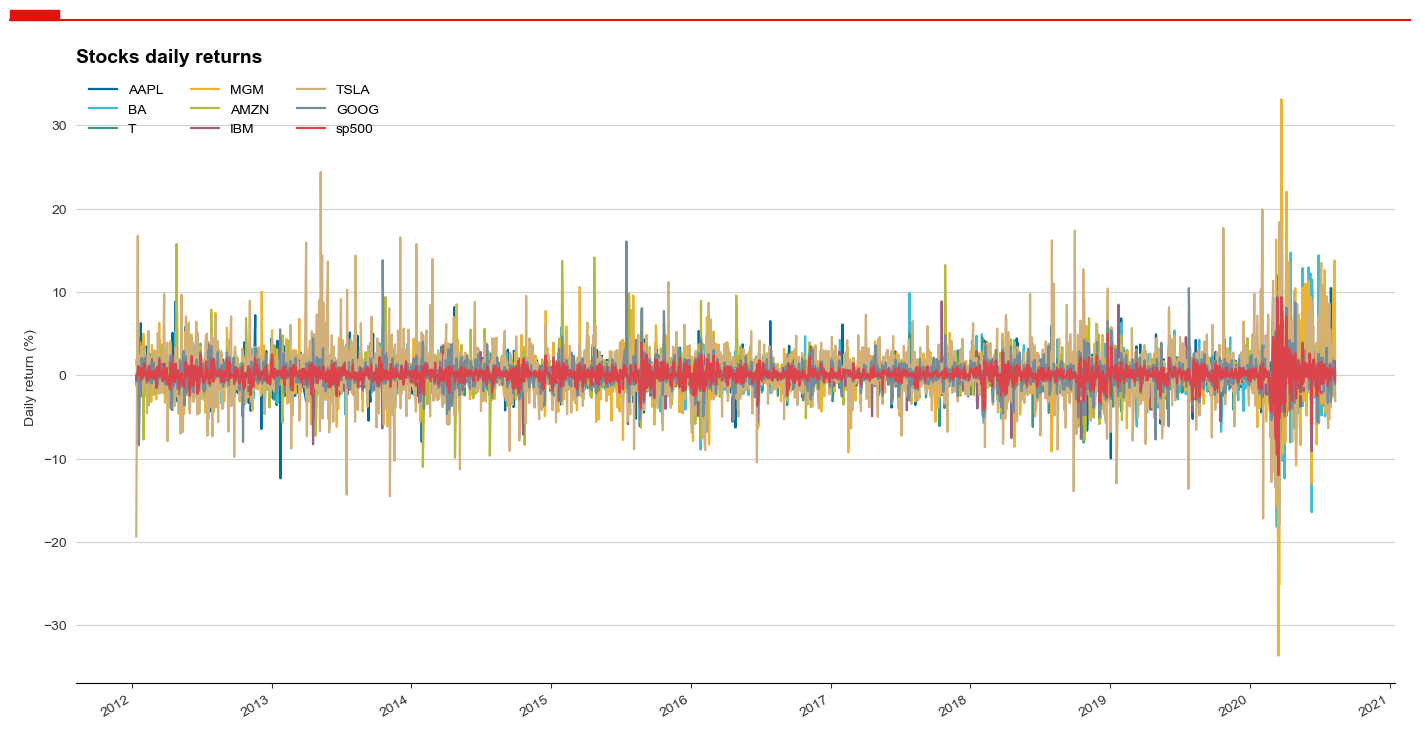

In [ ]:
plot_financial_data(returns * 100, "Stocks daily returns", "Daily return (%)")

**Comment.** Returns fluctuate around zero without a trend, which is why we model returns and not prices.
- **Volatility clusters.** Calm and turbulent periods alternate, and March 2020 dominates: MGM with around −33% and +33% in March, Boeing with −24% and +24% in the same timeframe.
- **Tesla is the most volatile stock** over the sample. The S&P 500 moves least, which can be interpreted as the diversification effect of holding a portfolio of stocks, in line with Markowitz.

### 5.2 Correlations between daily returns
Diversification works only to the extent that assets do not move together.

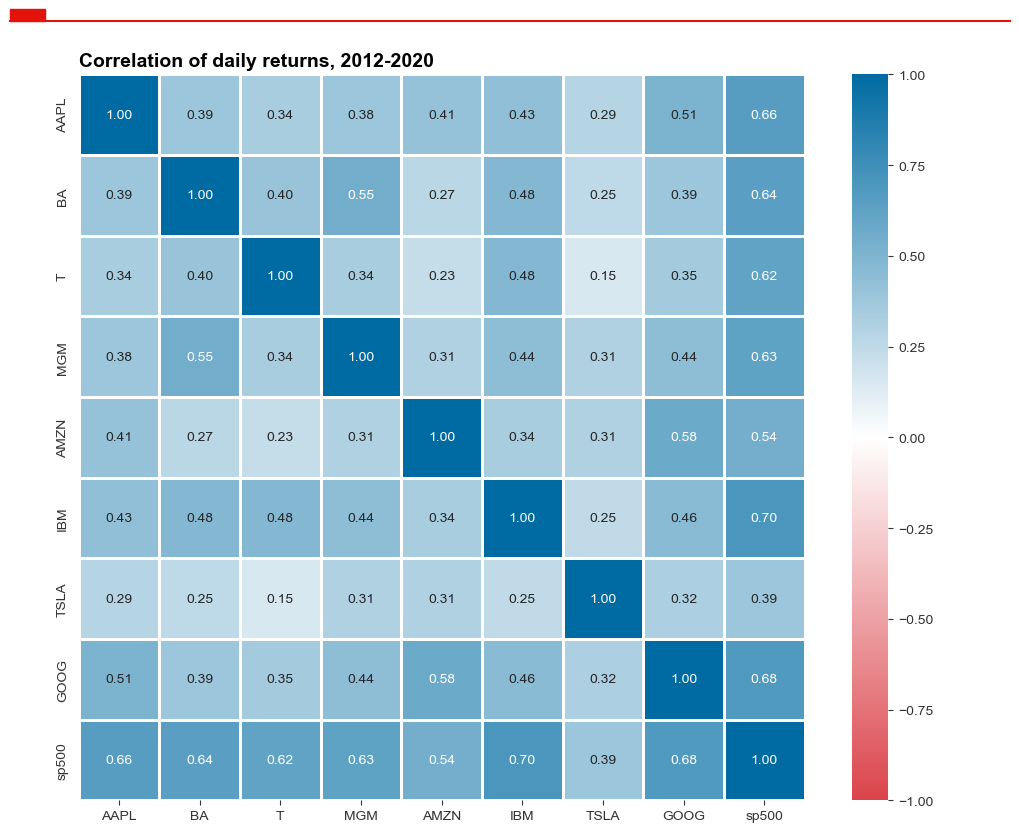

In [ ]:
corr = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=ECONOMIST_DIVERGING, vmin=-1, vmax=1, square=True, linewidths=1)
plt.title("Correlation of daily returns, 2012-2020")
plt.grid(False)
show()

In [ ]:
corr_with_sp500 = corr["sp500"].drop("sp500").sort_values(ascending=False)
print("Correlation with the S&P 500:")
print(corr_with_sp500.round(3))

print("\nTop 2 stocks correlated with the S&P 500:", list(corr_with_sp500.index[:2]))
print("Correlation AMZN - BA:", round(corr.loc["AMZN", "BA"], 3))
print("Correlation MGM  - BA:", round(corr.loc["MGM", "BA"], 3))

Correlation with the S&P 500:
IBM    0.7040
GOOG   0.6850
AAPL   0.6570
BA     0.6420
MGM    0.6310
T      0.6170
AMZN   0.5400
TSLA   0.3880
Name: sp500, dtype: float64

Top 2 stocks correlated with the S&P 500: ['IBM', 'GOOG']
Correlation AMZN - BA: 0.267
Correlation MGM  - BA: 0.554


Full-sample correlations hide how relationships change. The 2020 crash is a natural experiment, so we split the sample.

In [ ]:
before = returns.loc[:"2019"]
during = returns.loc["2020":]

pd.DataFrame({
    "before 2020": [before["AMZN"].corr(before["BA"]), before["MGM"].corr(before["BA"])],
    "during 2020": [during["AMZN"].corr(during["BA"]), during["MGM"].corr(during["BA"])],
    "full sample": [corr.loc["AMZN", "BA"], corr.loc["MGM", "BA"]],
}, index=["AMZN - BA", "MGM - BA"])

,before 2020,during 2020,full sample
AMZN - BA,0.3229,0.2853,0.2675
MGM - BA,0.3600,0.7193,0.5542


**Comments – Task #5 (correlations)**
- Every pair is positively correlated (0.15 to 0.70). A common market factor drives all of them, so diversification reduces risk but cannot remove it.
- **Most correlated with the S&P 500: IBM (0.70) and Google (0.69)**, then Apple (0.66). Tesla is the least market-like (0.39).
- **AMZN–BA: 0.27**, one of the lowest pairs (the lowest is T–TSLA, at 0.15). A good diversification pair.
- **MGM–BA: 0.55**, the second-highest pair after AMZN–GOOG (0.58). Their correlation jumped from 0.36 before 2020 to **0.72 in 2020**. The correlation rose in the crisis, so a covariance matrix estimated in calm times understates crash risk.

### 5.3 Distribution of daily returns
Mean and variance describe an asset completely only if its returns are normal. `plot_return_histograms` draws each histogram with a normal curve of the same mean and standard deviation.

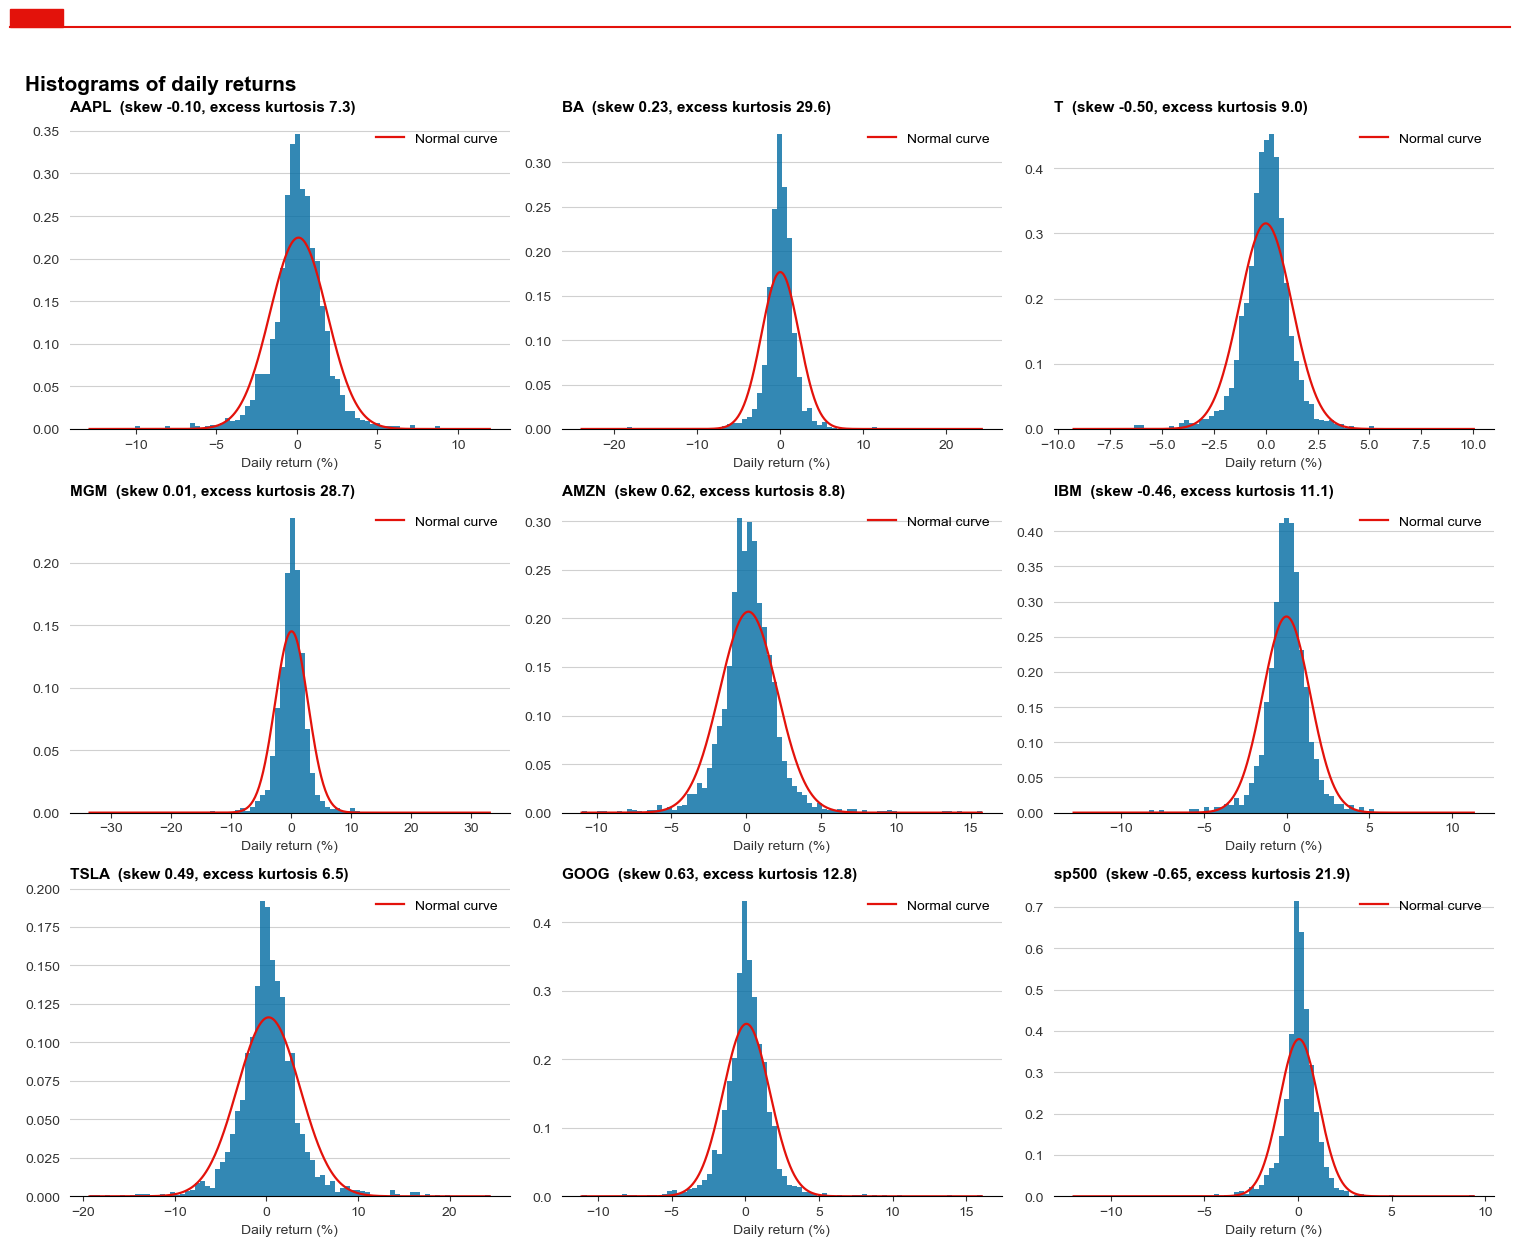

In [ ]:
def plot_return_histograms(returns):
    '''One histogram per column, with a normal curve of the same mean and standard deviation.'''
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    for ax, column in zip(axes.flat, returns.columns):
        r = returns[column] * 100                                   # in percent
        ax.hist(r, bins=80, density=True, color=ECONOMIST_COLORS[0], alpha=0.8)
        x = np.linspace(r.min(), r.max(), 400)
        ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=ECONOMIST_RED, label="Normal curve")
        ax.set_title(f"{column}  (skew {r.skew():.2f}, excess kurtosis {r.kurt():.1f})", fontsize=11)
        ax.set_xlabel("Daily return (%)")
        ax.legend()

    fig.suptitle("Histograms of daily returns", x=0.01, ha="left", fontsize=15, fontweight="bold")
    show()


plot_return_histograms(returns)

In [ ]:
pd.DataFrame({
    "ann. mean": returns.mean() * DAYS,
    "ann. volatility": returns.std() * np.sqrt(DAYS),
    "skewness": returns.skew(),
    "excess kurtosis": returns.kurt(),
    "worst day": returns.min(),
    "best day": returns.max(),
}).sort_values("ann. volatility", ascending=False)

,ann. mean,ann. volatility,skewness,excess kurtosis,worst day,best day
TSLA,0.6010,0.5446,0.4881,6.5244,-0.1933,0.2440
MGM,0.1630,0.4361,0.0075,28.7096,-0.3361,0.3311
BA,0.1662,0.3588,0.2273,29.5818,-0.2385,0.2432
AMZN,0.3810,0.3061,0.6201,8.7650,-0.1100,0.1575
AAPL,0.2715,0.2820,-0.0979,7.3196,-0.1286,0.1198
GOOG,0.2128,0.2518,0.6349,12.7677,-0.1110,0.1605
IBM,-0.0154,0.2272,-0.4641,11.0543,-0.1285,0.1130
T,0.0206,0.2008,-0.4975,9.0267,-0.0924,0.1002
sp500,0.1243,0.1665,-0.6516,21.8711,-0.1198,0.0938


**Jarque–Bera test.** A formal normality test built from a sample's skewness and excess kurtosis.

In [ ]:
def jb_test(df):
    '''Jarque-Bera normality test; JB is asymptotically chi-squared(2) under the null.'''
    n = len(df)
    S, K = df.skew(), df.kurt()                      # kurt() is already excess kurtosis
    JB = n / 6 * (S ** 2 + K ** 2 / 4)
    p_value = np.exp(-JB / 2)                        
    return pd.DataFrame({"JB": JB, "p_value": p_value})


jb_test(returns)

,JB,p_value
AAPL,"4,820.8714",0.0000
BA,"78,703.0604",0.0000
T,"7,415.4713",0.0000
MGM,"74,113.1805",0.0000
AMZN,"7,046.1127",0.0000
IBM,"11,065.1340",0.0000
TSLA,"3,913.1779",0.0000
GOOG,"14,802.5719",0.0000
sp500,"43,163.8298",0.0000


**Comment**
- The distributions are bell-shaped but **not normal**: the peaks are too high and the tails too fat. Excess kurtosis runs from 6.5 (TSLA) to 29.6 (BA) and 28.7 (MGM), against 0 for a normal distribution. MGM's −33.6% day is a 12-sigma move relative to its 2.7% daily standard deviation. **Jarque–Bera confirms this formally: p ≈ 0.0000 for all nine series**, under the null of normality.
- Width tracks volatility: Tesla is widest (54% a year), then MGM (44%) and Boeing (36%). AT&T is the narrowest stock (20%) and the diversified S&P 500 is narrower still (17%).
- Skewness differs in sign. The S&P 500 (−0.65), AT&T and IBM lean towards large losses, Amazon, Google and Tesla towards large gains.

Variance therefore understates tail risk, and the Sharpe ratio treats both tails alike.

**Optional – interactive histograms with Plotly.** `create_distplot` overlays the densities; you can hover, zoom and switch stocks off in the legend.

In [ ]:
def interactive_histograms(returns):
    '''Interactive overlaid histograms of daily returns (%) with Plotly.'''
    try:
        import plotly.figure_factory as ff
    except ImportError:
        print("Plotly is not installed -> run `pip install plotly` to see this chart.")
        return

    data = [returns[column] * 100 for column in returns.columns]
    fig = ff.create_distplot(data, list(returns.columns), bin_size=0.3, show_rug=False, colors=ECONOMIST_COLORS)
    fig.update_layout(title="<b>Distribution of daily returns (%)</b>", title_x=0.01, template="simple_white",
                      font_family="Arial", width=1000, height=550)
    fig.show()


interactive_histograms(returns)

## Task #6 – Portfolio weights
### 6.1 Simulation: the empirical efficient frontier
With annual mean returns $\mu$ and annual covariance matrix $\Sigma$:

$$E[R_p] = w^\top \mu, \qquad \sigma_p = \sqrt{w^\top \Sigma\, w}, \qquad SR_p = E[R_p] / \sigma_p .$$

`simulate_portfolios` draws 10,000 long-only weight vectors (random numbers rescaled to sum to 1, as in the slides), stores return, variance, volatility, Sharpe ratio and weights for each, and returns the one with the highest Sharpe ratio: the simulated **tangency portfolio**.

In [ ]:
def portfolio_stats(weights, returns):
    '''Annual expected return, volatility and Sharpe ratio of one portfolio.'''
    returns = returns[weights.index]                      # same stock order as the weights
    exp_return = weights @ returns.mean() * DAYS
    volatility = np.sqrt(weights @ returns.cov() @ weights * DAYS)
    return exp_return, volatility, exp_return / volatility


def simulate_portfolios(returns, n_portfolios=N_PORTFOLIOS, seed=SEED):
    '''
    Simulate random long-only portfolios.
    Returns the maximum Sharpe ratio, the weights of that portfolio and a table with all portfolios.
    '''
    rng = np.random.default_rng(seed)
    mu = returns.mean().to_numpy() * DAYS                 # annual mean returns
    cov = returns.cov().to_numpy() * DAYS                 # annual covariance matrix

    rows = []
    for _ in range(n_portfolios):
        w = rng.random(len(mu))
        w = w / w.sum()                                   # weights sum to 1
        exp_return = w @ mu
        variance = w @ cov @ w
        rows.append([exp_return, variance, np.sqrt(variance), exp_return / np.sqrt(variance), *w])

    results = pd.DataFrame(rows, columns=["Return", "Variance", "Volatility", "Sharpe", *returns.columns])

    best = results["Sharpe"].idxmax()
    best_weights = results.loc[best, returns.columns].astype(float).rename("weight")
    return results.loc[best, "Sharpe"], best_weights, results

In [ ]:
max_sharpe, tangency_weights, sim_results = simulate_portfolios(stock_returns)
tan_return, tan_vol, _ = portfolio_stats(tangency_weights, stock_returns)

print(f"Maximum Sharpe ratio : {max_sharpe:.3f}")
print(f"Expected return      : {tan_return:.2%}")
print(f"Volatility           : {tan_vol:.2%}")
print("\nTangency portfolio weights:")
print(tangency_weights.sort_values(ascending=False).map("{:.2%}".format).to_string())

Maximum Sharpe ratio : 1.426
Expected return      : 34.14%
Volatility           : 23.94%

Tangency portfolio weights:
AMZN    31.18%
AAPL    23.14%
TSLA    18.97%
GOOG    17.29%
BA       4.25%
T        3.14%
IBM      1.19%
MGM      0.83%


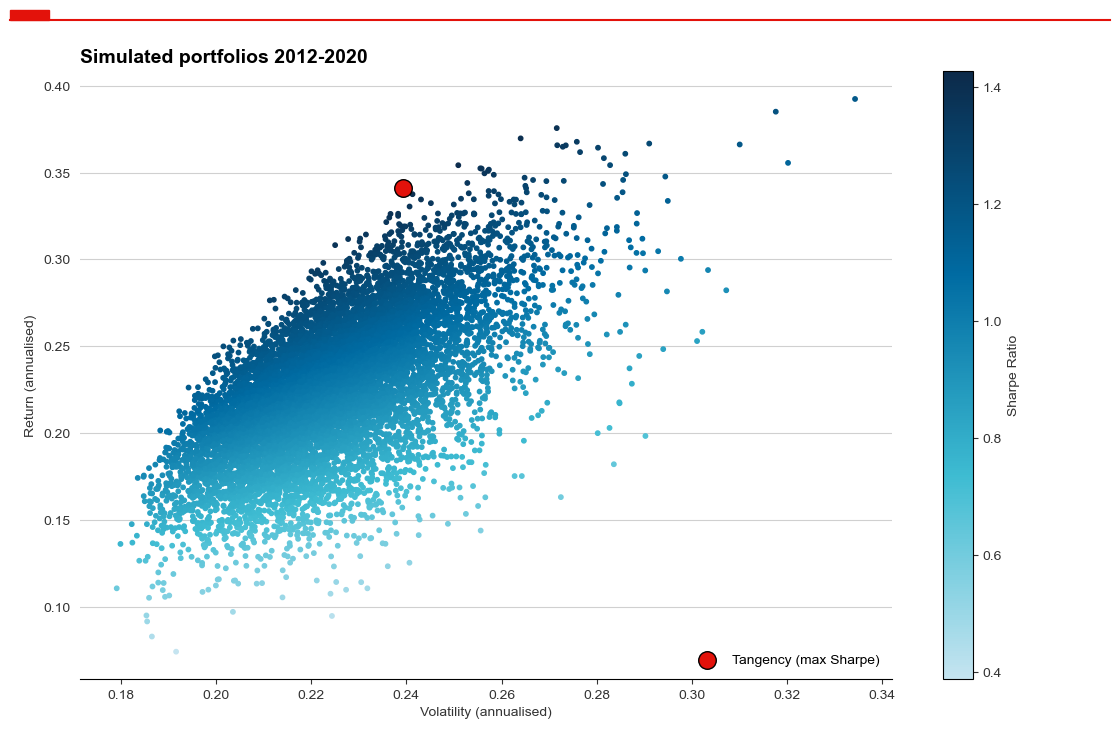

In [ ]:
def plot_portfolios(results, title, markers=None, frontier=None):
    '''
    Scatter plot of simulated portfolios, coloured by Sharpe ratio.
    markers : optional {label: (volatility, return, color)} of portfolios to highlight
    frontier: optional (volatilities, returns) of the efficient frontier
    '''
    plt.figure(figsize=(11, 7))
    plt.scatter(results["Volatility"], results["Return"], c=results["Sharpe"], cmap=ECONOMIST_BLUES, s=10)
    plt.colorbar(label="Sharpe Ratio")

    if frontier is not None:
        plt.plot(*frontier, color=ECONOMIST_COLORS[2], lw=2.5, label="Efficient frontier")
    for label, (vol, ret, color) in (markers or {}).items():
        plt.scatter(vol, ret, color=color, s=160, edgecolors="black", label=label)

    plt.xlabel("Volatility (annualised)")
    plt.ylabel("Return (annualised)")
    plt.title(title)
    if markers or frontier is not None:
        plt.legend(loc="lower right")
    show()


plot_portfolios(sim_results, "Simulated portfolios 2012-2020",
                markers={"Tangency (max Sharpe)": (tan_vol, tan_return, ECONOMIST_RED)})

**Weights (2012–2020):** AMZN 31.2%, AAPL 23.1%, TSLA 19.0%, GOOG 17.3%, BA 4.2%, T 3.1%, IBM 1.2%, MGM 0.8%. Expected return 34.1%, volatility 23.9%, **Sharpe ratio 1.43**.

- The cloud has the bullet shape of the slides; its upper-left edge is the empirical efficient frontier, and the tangency portfolio sits on that edge.
- About 90% of the weight goes to the four tech winners, which combine the highest mean returns (21–60% p.a.) with moderate mutual correlations. Tesla has the highest mean (60%) but gets under 20% because of its 54% volatility, while AT&T and IBM are low-risk with near-zero mean returns and are barely used.
- Eight stocks already leave the fund exposed to concentration risk, and the optimiser makes this worse: the tangency weights load on a handful of names rather than spreading across the set.

### 6.2 Optional – the efficient frontier via optimisation
Random weights rarely land on the frontier. For a target return $\bar R$ we therefore let SciPy find the lowest-variance portfolio:

$$\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad w^\top\mu = \bar R,\;\; \textstyle\sum_i w_i = 1,\;\; 0 \le w_i \le 1 .$$

`efficient_frontier` repeats this over a grid of target returns and returns the curve. The same solver gives the **exact tangency portfolio** (maximum Sharpe ratio) and the **global minimum-variance (GMV) portfolio**, our secondary benchmark.

In [ ]:
def optimal_weights(returns, objective, target_return=None):
    '''
    Long-only weights (0 <= w <= 1, sum = 1) that minimise objective(w, mu, cov).
    If target_return is given, the portfolio must also earn that annual return.
    '''
    mu = returns.mean().to_numpy() * DAYS
    cov = returns.cov().to_numpy() * DAYS
    n = len(mu)

    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    if target_return is not None:
        constraints.append({"type": "eq", "fun": lambda w: w @ mu - target_return})

    result = minimize(lambda w: objective(w, mu, cov), x0=np.ones(n) / n, method="SLSQP",
                      bounds=[(0, 1)] * n, constraints=constraints,
                      options={"ftol": 1e-12, "maxiter": 1000})   # tight tolerance: variances are small numbers
    return pd.Series(result.x, index=returns.columns)


def variance(w, mu, cov):
    return w @ cov @ w


def negative_sharpe(w, mu, cov):
    return -(w @ mu) / np.sqrt(w @ cov @ w)                # minimising -Sharpe = maximising Sharpe


def min_variance(returns, target_return=None):
    return optimal_weights(returns, variance, target_return)


def max_sharpe_weights(returns):
    return optimal_weights(returns, negative_sharpe)


def efficient_frontier(returns, n_points=50):
    '''
    Efficient frontier: the lowest volatility for every target return between the
    GMV portfolio and the best single stock. Returns (volatilities, target returns).
    '''
    gmv_return = portfolio_stats(min_variance(returns), returns)[0]
    target_returns = np.linspace(gmv_return, (returns.mean() * DAYS).max(), n_points)
    volatilities = [portfolio_stats(min_variance(returns, target), returns)[1] for target in target_returns]
    return volatilities, target_returns

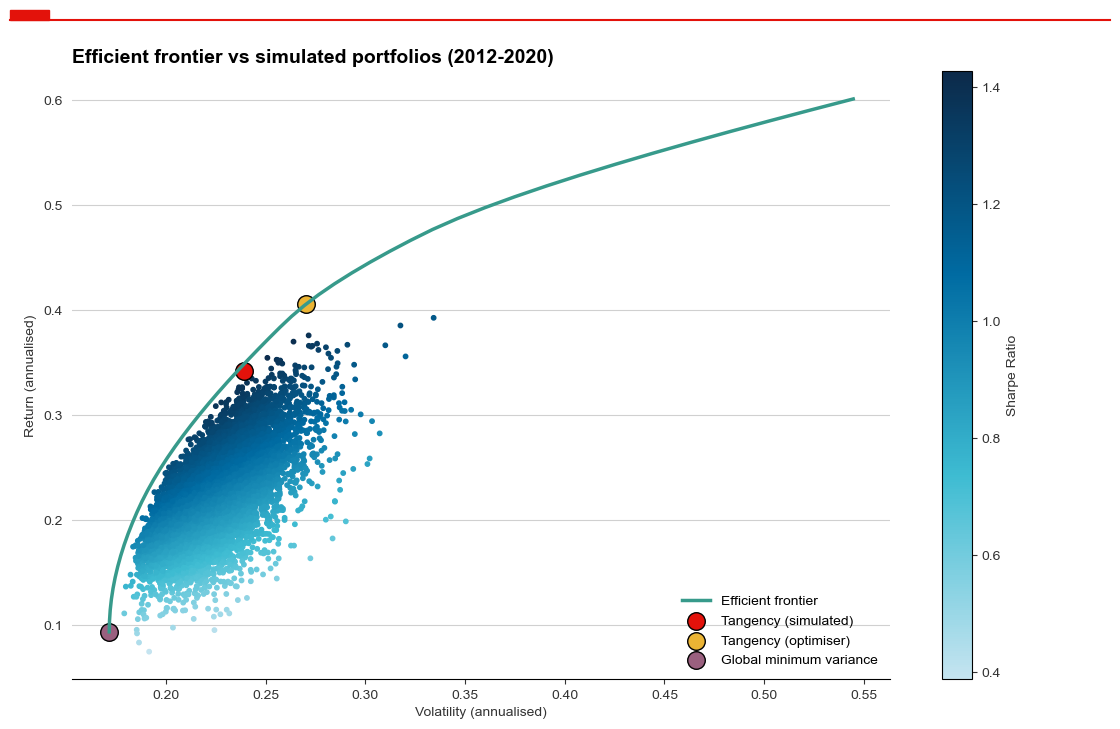

Tangency (simulated) : return 34.14% | vol 23.94% | Sharpe 1.426
Tangency (optimiser) : return 40.53% | vol 27.02% | Sharpe 1.500
Global min. variance : return 9.31% | vol 17.16% | Sharpe 0.542


,Tangency (simulated),Tangency (optimiser),Global min. variance
AAPL,23.1%,25.8%,7.6%
BA,4.2%,0.0%,0.0%
T,3.1%,0.0%,48.7%
MGM,0.8%,0.0%,0.0%
AMZN,31.2%,50.3%,9.6%
IBM,1.2%,0.0%,21.1%
TSLA,19.0%,23.9%,0.3%
GOOG,17.3%,0.0%,12.8%


In [ ]:
# Special portfolios
exact_tangency_weights = max_sharpe_weights(stock_returns)
gmv_weights = min_variance(stock_returns)
exact_return, exact_vol, exact_sharpe = portfolio_stats(exact_tangency_weights, stock_returns)
gmv_return, gmv_vol, gmv_sharpe = portfolio_stats(gmv_weights, stock_returns)

plot_portfolios(sim_results, "Efficient frontier vs simulated portfolios (2012-2020)",
                frontier=efficient_frontier(stock_returns),
                markers={"Tangency (simulated)": (tan_vol, tan_return, ECONOMIST_RED),
                         "Tangency (optimiser)": (exact_vol, exact_return, ECONOMIST_COLORS[3]),
                         "Global minimum variance": (gmv_vol, gmv_return, ECONOMIST_COLORS[5])})

print(f"Tangency (simulated) : return {tan_return:.2%} | vol {tan_vol:.2%} | Sharpe {max_sharpe:.3f}")
print(f"Tangency (optimiser) : return {exact_return:.2%} | vol {exact_vol:.2%} | Sharpe {exact_sharpe:.3f}")
print(f"Global min. variance : return {gmv_return:.2%} | vol {gmv_vol:.2%} | Sharpe {gmv_sharpe:.3f}")

pd.DataFrame({"Tangency (simulated)": tangency_weights,
              "Tangency (optimiser)": exact_tangency_weights,
              "Global min. variance": gmv_weights}).map("{:.1%}".format)

- The optimised frontier **envelops the simulated cloud**: none of the 10,000 random portfolios lies beyond it. We draw only the efficient part, from the GMV portfolio upwards; it ends at 100% Tesla (60% return, 54% volatility).
- **The simulation never reaches the frontier**, because random weights that sum to 1 cluster around 1/8 per stock and rarely produce concentrated portfolios. The exact tangency portfolio is a corner solution: **AMZN 50.3%, AAPL 25.8%, TSLA 23.9%**, zero elsewhere, with a Sharpe ratio of **1.50** against 1.43 simulated.
- The GMV portfolio is the opposite: 49% AT&T and 21% IBM, the least volatile stocks, at 17.2% volatility and 9.3% return. It needs no return forecasts.
- The optimiser loads on the assets with the highest *estimated* means, which are also the least reliable estimates. This is the error-maximisation problem of mean-variance optimisation.

### 6.3 Performance of the tangency portfolio over the sample
We invest \$1 on 2012-01-12 in the tangency portfolio and in both benchmarks (i. Equal weight benchmark - 1/N, ii. Global Minimum Variance Portfolio). Since the broker charges no fees, each portfolio is rebalanced to its target weights every day, so its daily return is `stock_returns @ weights`. The growth charts use a log scale, as in Task 3. The tangency weights are the simulated ones (6.1), while GMV comes from the optimiser (6.2); the same holds in Task 7.

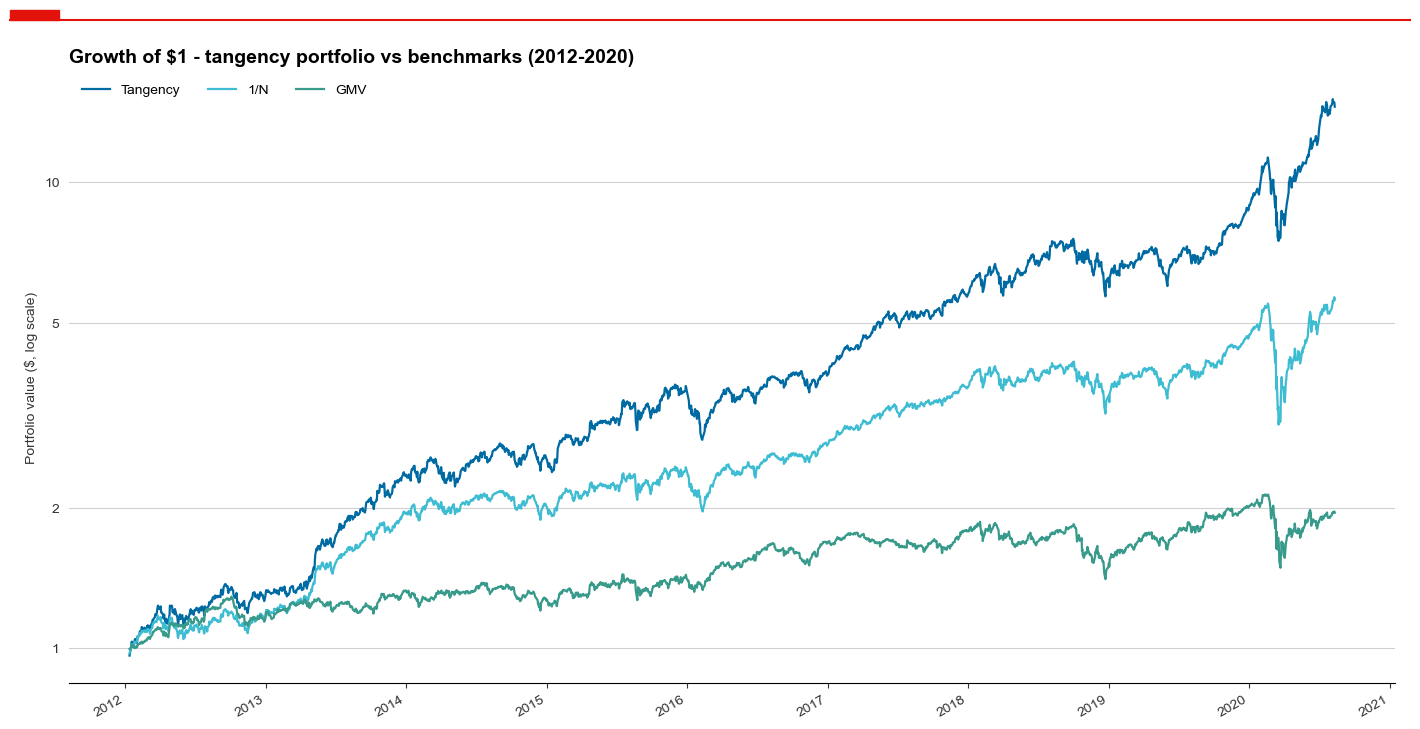

In [ ]:
def performance_table(daily_returns, benchmark="1/N"):
    '''Realised performance of strategies (one column of daily returns per strategy).'''
    values = (1 + daily_returns).cumprod()                         # growth of $1
    years = len(daily_returns) / DAYS
    volatility = daily_returns.std() * np.sqrt(DAYS)

    table = pd.DataFrame({
        "final value of $1": values.iloc[-1],
        "CAGR": values.iloc[-1] ** (1 / years) - 1,
        "volatility": volatility,
        "Sharpe": daily_returns.mean() * DAYS / volatility,
        "max drawdown": (values / values.cummax().clip(lower=1) - 1).min(),   # worst fall from a previous peak
    })

    # Comparison with the benchmark
    excess_returns = daily_returns.sub(daily_returns[benchmark], axis=0)
    table["excess CAGR"] = table["CAGR"] - table.loc[benchmark, "CAGR"]
    table["tracking error"] = excess_returns.std() * np.sqrt(DAYS)
    table["information ratio"] = excess_returns.mean() * DAYS / table["tracking error"]
    return table


equal_weights = pd.Series(1 / len(stocks), index=stocks)          # primary benchmark

in_sample = pd.DataFrame({
    "Tangency": stock_returns @ tangency_weights,
    "1/N": stock_returns @ equal_weights,
    "GMV": stock_returns @ gmv_weights,
})

plot_financial_data((1 + in_sample).cumprod(), "Growth of $1 - tangency portfolio vs benchmarks (2012-2020)", "Portfolio value ($, log scale)", log_scale=True)

- \$1 becomes **\$14.52** in the tangency portfolio, \$5.60 in 1/N and \$1.95 in GMV.
- GMV does what it is built for: the lowest volatility (17.2%). Its return is low because its main holdings, AT&T and IBM, barely moved.

All of this is in-sample: the weights already knew the outcome. Task 7 removes that advantage.

## Task #7 – Testing portfolio theory
Task 6 is in-sample: the weights were chosen on the same returns they were measured on. A fund manager only knows the past, so we
1. estimate the tangency portfolio and the GMV benchmark on **2012–2015**,
2. hold those weights over **2016–2020**,
3. compare what the model expected with what was realised.

In [ ]:
train_returns = stock_returns.loc[:"2015"]    # estimation window
test_returns = stock_returns.loc["2016":]     # out-of-sample window

train_max_sharpe, train_tangency_weights, train_sim_results = simulate_portfolios(train_returns)
train_return, train_vol, _ = portfolio_stats(train_tangency_weights, train_returns)
train_gmv_weights = min_variance(train_returns)

print(f"2012-2015 tangency: Sharpe {train_max_sharpe:.3f} | expected return {train_return:.2%} | volatility {train_vol:.2%}")

pd.DataFrame({"Tangency 2012-2015": train_tangency_weights,
              "Tangency 2012-2020 (Task 6)": tangency_weights,
              "GMV 2012-2015": train_gmv_weights}).map("{:.1%}".format)

2012-2015 tangency: Sharpe 1.655 | expected return 33.38% | volatility 20.17%


,Tangency 2012-2015,Tangency 2012-2020 (Task 6),GMV 2012-2015
AAPL,10.4%,23.1%,6.5%
BA,23.0%,4.2%,15.9%
T,7.0%,3.1%,49.7%
MGM,2.5%,0.8%,0.0%
AMZN,26.7%,31.2%,0.9%
IBM,0.4%,1.2%,19.5%
TSLA,19.9%,19.0%,0.0%
GOOG,10.1%,17.3%,7.5%


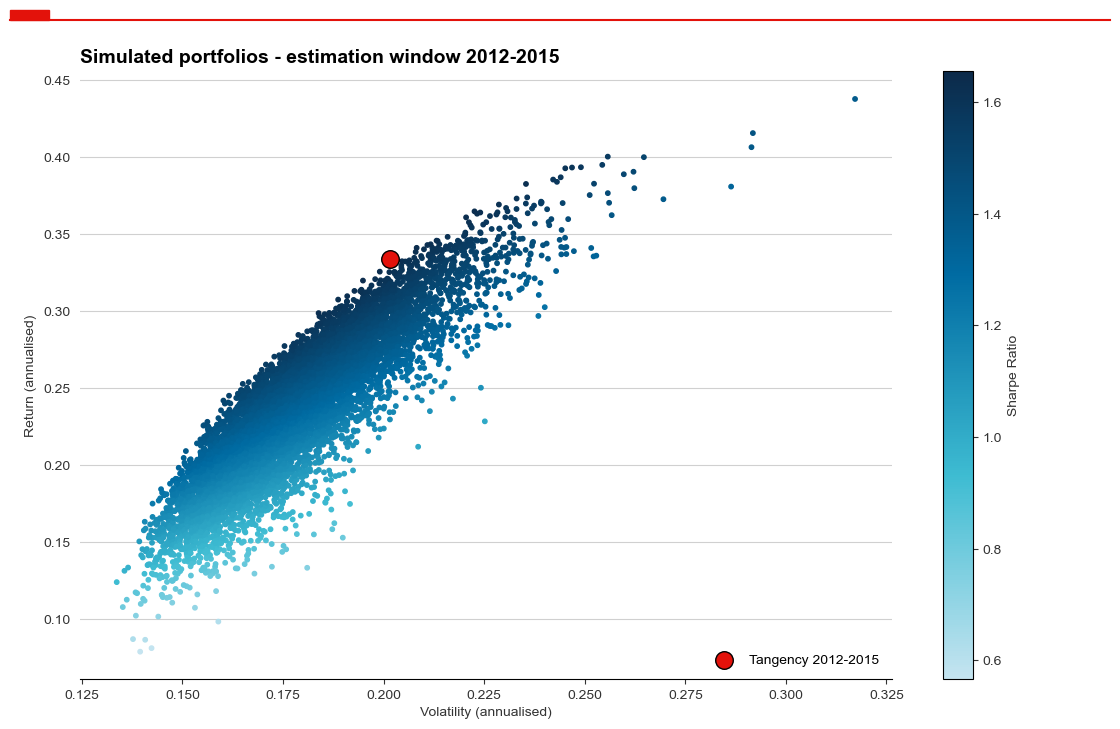

In [ ]:
plot_portfolios(train_sim_results, "Simulated portfolios - estimation window 2012-2015",
                markers={"Tangency 2012-2015": (train_vol, train_return, ECONOMIST_RED)})

### 7.1 Out-of-sample performance
\$1 invested at the start of 2016 in the 2012–2015 tangency portfolio and in the two benchmarks, all estimated on the same information. The *hindsight* tangency portfolio of 2016–2020 is shown as a reference, not a benchmark: it has the highest simulated Sharpe ratio in the test window and requires perfect foresight.

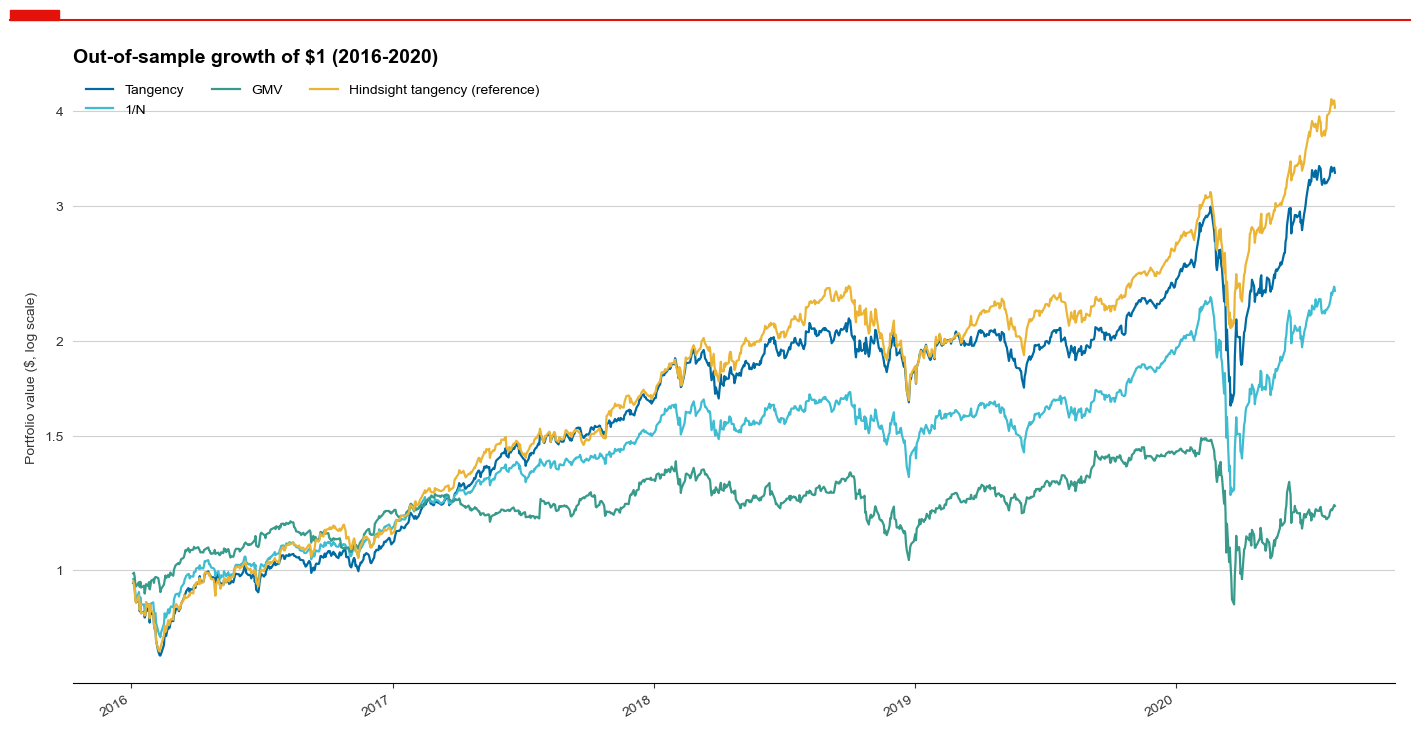

In [ ]:
hindsight_weights = simulate_portfolios(test_returns)[1]

out_of_sample = pd.DataFrame({
    "Tangency": test_returns @ train_tangency_weights,
    "1/N": test_returns @ equal_weights,
    "GMV": test_returns @ train_gmv_weights,
    "Hindsight tangency (reference)": test_returns @ hindsight_weights,
})

plot_financial_data((1 + out_of_sample).cumprod(), "Out-of-sample growth of $1 (2016-2020)", "Portfolio value ($, log scale)", log_scale=True)

**Expected vs realised.** Return and volatility measured on 2012–2015, next to the values realised over 2016–2020.

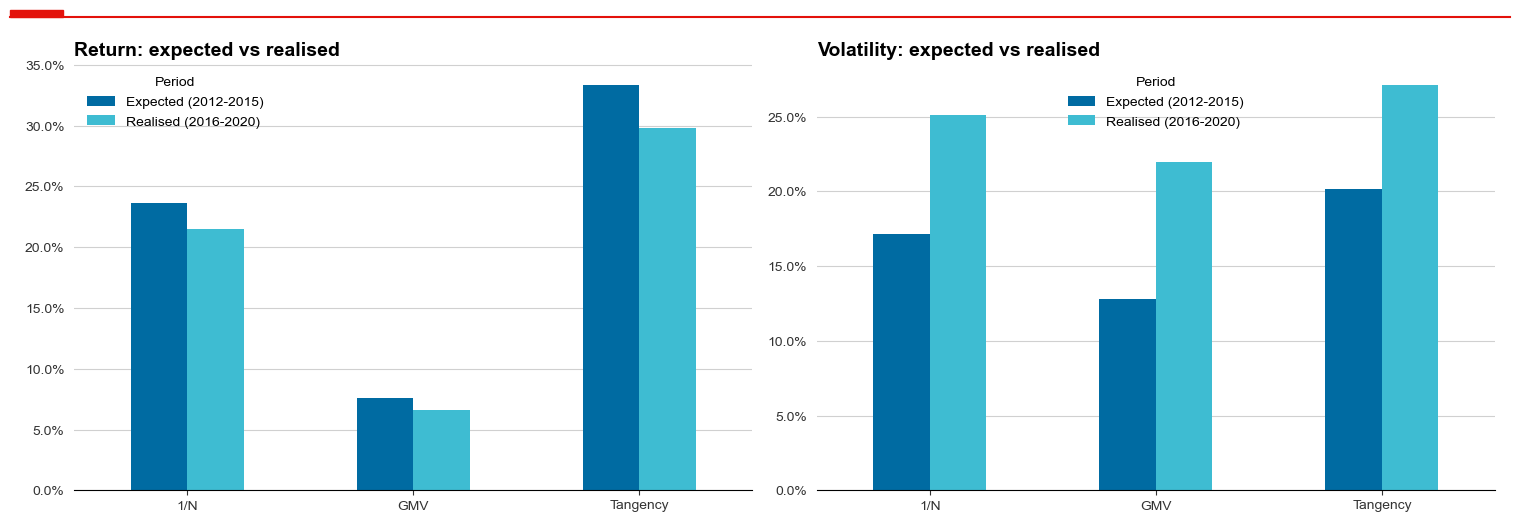

,Strategy,Period,Return,Volatility,Sharpe
0,Tangency,Expected (2012-2015),0.3338,0.2017,1.6551
1,Tangency,Realised (2016-2020),0.2980,0.2715,1.0976
2,1/N,Expected (2012-2015),0.2366,0.1714,1.3803
3,1/N,Realised (2016-2020),0.2152,0.2510,0.8573
4,GMV,Expected (2012-2015),0.0758,0.1282,0.5914
5,GMV,Realised (2016-2020),0.0665,0.2199,0.3022


In [ ]:
strategies = {"Tangency": train_tangency_weights, "1/N": equal_weights, "GMV": train_gmv_weights}

rows = []
for name, weights in strategies.items():
    for period, data in [("Expected (2012-2015)", train_returns), ("Realised (2016-2020)", test_returns)]:
        exp_return, volatility, sharpe = portfolio_stats(weights, data)
        rows.append([name, period, exp_return, volatility, sharpe])

expected_vs_realised = pd.DataFrame(rows, columns=["Strategy", "Period", "Return", "Volatility", "Sharpe"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ["Return", "Volatility"]):
    expected_vs_realised.pivot(index="Strategy", columns="Period", values=metric).plot.bar(ax=ax, rot=0)
    ax.set_title(f"{metric}: expected vs realised")
    ax.set_xlabel("")
    ax.grid(False, axis="x")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
show()

expected_vs_realised

**Weights from 2012–2015:** AMZN 26.7%, BA 23.0%, TSLA 19.9%, AAPL 10.4%, GOOG 10.1%, T 7.0%, MGM 2.5%, IBM 0.4%. Boeing gets 23% instead of 4% and Apple 10% instead of 23% – the estimated weights are unstable. The GMV portfolio of the same window holds mainly AT&T (50%), IBM (20%) and Boeing (16%).

**Performance.** \$1 grows to **\$3.32** against \$2.33 for 1/N and \$1.21 for GMV.

**Expected vs realised.** The return held up (33.4% → 29.8%), risk did not: 20.2% → 27.2% for the tangency portfolio, 17.1% → 25.1% for 1/N, 12.8% → 22.0% for GMV. Sharpe ratios fell by about a third (1.66 → 1.10 and 1.38 → 0.86) and almost halved for GMV (0.59 → 0.30). The *ranking* of risk survived, GMV least and tangency most volatile, so the risk forecasts were informative but too low in level, because the test window contains the COVID crash.


### 7.2 Optional – yearly rebalancing
A single estimation window may be lucky. At the start of every year (2013–2020) we therefore re-estimate the tangency portfolio on **last year's returns only** and hold it for the year. GMV is re-estimated the same way; 1/N keeps equal weights.

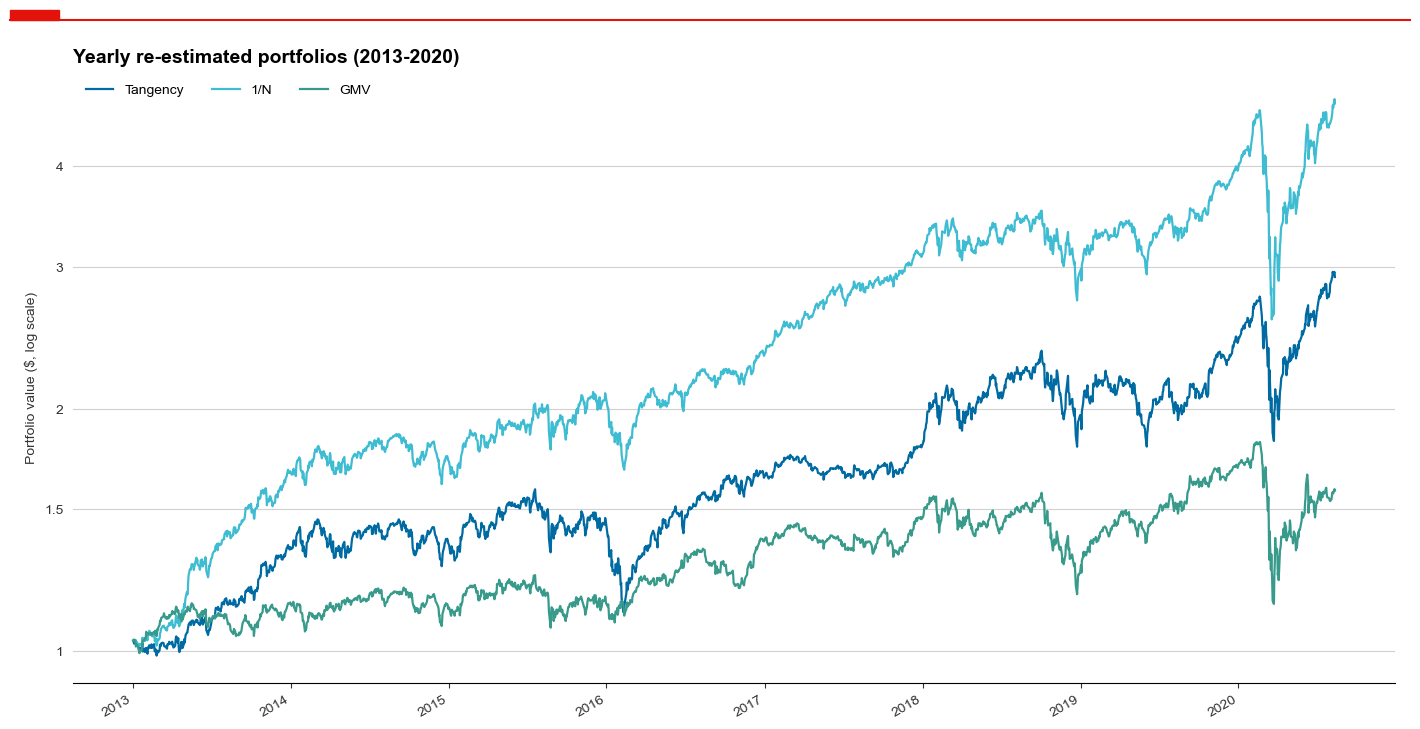

,final value of $1,CAGR,volatility,Sharpe,max drawdown,excess CAGR,tracking error,information ratio
Tangency,2.9144,0.1511,0.2191,0.7522,-0.3381,-0.0775,0.0930,-0.7118
1/N,4.7845,0.2286,0.2228,1.0369,-0.4499,0.0000,0.0000,NaN
GMV,1.5830,0.0623,0.1870,0.4171,-0.3703,-0.1663,0.1163,-1.3152


In [ ]:
tangency_daily, gmv_daily, tangency_weights_by_year = [], [], {}

for year in range(2013, 2021):
    last_year = stock_returns.loc[str(year - 1)]
    this_year = stock_returns.loc[str(year)]

    w_tangency = simulate_portfolios(last_year)[1]      # estimated on last year only
    w_gmv = min_variance(last_year)

    tangency_daily.append(this_year @ w_tangency)       # held during this year
    gmv_daily.append(this_year @ w_gmv)
    tangency_weights_by_year[year] = w_tangency

rolling = pd.DataFrame({
    "Tangency": pd.concat(tangency_daily),
    "1/N": stock_returns.loc["2013":] @ equal_weights,
    "GMV": pd.concat(gmv_daily),
})
tangency_weights_by_year = pd.DataFrame(tangency_weights_by_year).T

plot_financial_data((1 + rolling).cumprod(), "Yearly re-estimated portfolios (2013-2020)", "Portfolio value ($, log scale)", log_scale=True)
performance_table(rolling)

In [ ]:
ax = tangency_weights_by_year.plot.bar(stacked=True, figsize=(14, 6), rot=0, width=0.8)
ax.set_title("Tangency weights chosen at the start of each year (estimated on the previous year)")
ax.grid(False, axis="x")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
show()

display(tangency_weights_by_year.map("{:.1%}".format))

# Return of each strategy in each calendar year
yearly_returns = (1 + rolling).groupby(rolling.index.year).prod() - 1
yearly_returns.map("{:.1%}".format)

NameError: name 'tangency_weights_by_year' is not defined

| 2013–2020 | \$1 becomes | CAGR | Sharpe | Max drawdown | Excess CAGR vs 1/N | Information ratio |
|---|---|---|---|---|---|---|
| Tangency, yearly | \$2.91 | 15.1% | 0.75 | −33.8% | **−7.7 pp** | **−0.71** |
| **Equal weight (1/N)** | **\$4.78** | **22.9%** | **1.04** | −45.0% | – | – |
| GMV, yearly | \$1.58 | 6.2% | 0.42 | −37.0% | −16.6 pp | −1.32 |

- Re-estimated every year, the tangency portfolio **loses 7.7 pp a year** to the benchmark and beats it in only 2 of 8 years (2016 and 2018). GMV is worse still, so neither optimised portfolio beats naive diversification here.
- **The weights swing from year to year.** Boeing gets 33% in 2014 and 45% in 2018, AT&T and IBM together 67% in 2017, Amazon 43% in 2016, AT&T 32% in 2020.
- What it does deliver is stability: a smaller drawdown than 1/N and a positive return every year, including 2018 (+9.7% while 1/N lost 4.1%).
- **Cause: estimation error.** One year of data gives an annual mean whose standard error is as large as the stock's volatility, 20–55 pp. The optimiser concentrates the portfolio in that noise. Zero fees flatter the strategy further, since its turnover is high.

## Conclusion
**Can Markowitz optimisation beat a fair benchmark?** Measured against the equal-weight portfolio of the same eight stocks, so that only the optimisation is judged and not the hindsight choice of stocks:

| Test | Growth of \$1: Tangency vs 1/N | Answer |
|---|---|---|
| In-sample 2012–2020 | \$14.52 vs \$5.60 | Yes, with perfect hindsight |
| Split 2012–15 → 2016–20 | \$3.32 vs \$2.33 | Yes in this one window, but risk underestimated by 7 pp |
| Yearly re-estimation 2013–2020 | \$2.91 vs \$4.78 | **No** |

The result depends on how much data the estimates use. Estimated on four years (7.1), the tangency portfolio beat 1/N out of sample; estimated on one year (7.2), the weights swing with the estimation error in the mean returns and lose to 1/N. Out of sample, risk was also underestimated: correlations rose in 2020 (5.2) and March 2020 brought extreme daily moves (5.1).